In [20]:
 import sys; print(sys.executable)

c:\Users\aadit\OneDrive\Desktop\barnsley_fernPyTorch\.venv\Scripts\python.exe


In [21]:
import torch
import numpy as np

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [23]:
n_points = 100000
n_iterations = 50

In [24]:
# Classic Barnsley fern affine transformations.
# Each transform maps (x, y) -> (a*x + b*y + e, c*x + d*y + f)
# Coefficients: [a, b, c, d, e, f]
coeffs = torch.tensor([
    [0.00,  0.00, 0.00, 0.16, 0.00, 0.00],  # f1: stem
    [0.85,  0.04, -0.04, 0.85, 0.00, 1.60],  # f2: successively smaller leaflets
    [0.20, -0.26, 0.23, 0.22, 0.00, 1.60],  # f3: largest left-hand leaflet
    [-0.15, 0.28, 0.26, 0.24, 0.00, 0.44],  # f4: largest right-hand leaflet
], dtype=torch.float32, device=device)

# Probability of selecting each transformation at every iteration
probabilities = torch.tensor([0.01, 0.85, 0.07, 0.07], dtype=torch.float32, device=device)

In [25]:
# n_points independent starting positions, all at the origin (0, 0)
points = torch.zeros((n_points, 2), dtype=torch.float32, device=device)

# Storage for every point's position at every iteration, for the final plot
history = torch.zeros((n_iterations, n_points, 2), dtype=torch.float32, device=device)

In [26]:
# Main iteration loop: at every step, each point independently and randomly
# picks one of the 4 rules (weighted by `probabilities`) and applies its
# affine transformation. All n_points points are updated in parallel.
for i in range(n_iterations):
    # For each point, sample a rule index in [0, 4) according to `probabilities`
    rule_idx = torch.multinomial(probabilities, n_points, replacement=True)  # (n_points,)

    # Gather each point's chosen coefficients: [a, b, c, d, e, f]
    a, b, c, d, e, f = coeffs[rule_idx].unbind(dim=1)  # each (n_points,)

    x, y = points.unbind(dim=1)  # each (n_points,)
    x_new = a * x + b * y + e
    y_new = c * x + d * y + f

    points = torch.stack((x_new, y_new), dim=1)  # (n_points, 2)
    history[i] = points

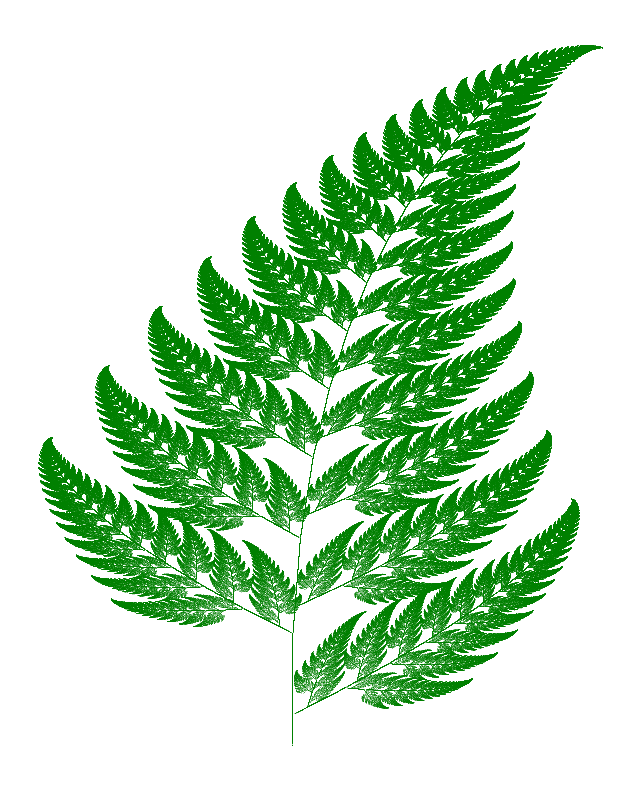

In [27]:
import matplotlib.pyplot as plt

# Flatten across all iterations and points into a single (n_iterations * n_points, 2) cloud
all_points = history.reshape(-1, 2).cpu().numpy()

plt.figure(figsize=(8, 10))
plt.scatter(all_points[:, 0], all_points[:, 1], s=0.1, c='green', linewidths=0)
plt.axis('off')
plt.show()